# 02 - Metric Anomaly Detection

Notebook này dùng detector registry để tránh chọn thuật toán theo cảm tính cho từng incident.

Luồng chính:

1. `metric_detector_map`: map metric family với detector phù hợp.
2. Baseline IQR và EWMA là detector chính vì data-driven hơn fixed threshold.
3. Threshold chỉ dùng như operational confirmation/severity rule.
4. Isolation Forest dùng làm supporting multivariate detector.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "g2-data" / "g2").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing g2-data/g2")

ROOT = find_project_root()
DATA = ROOT / "g2-data" / "g2"
METRICS = DATA / "metrics"
PLOTS = ROOT / "lab" / "plots"
RESULTS = ROOT / "lab" / "results"
PLOTS.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

def format_time_axis(ax, interval=3):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.tick_params(axis="x", labelrotation=0, labelsize=8, labelbottom=True)

def load_metric(name):
    df = pd.read_csv(METRICS / f"{name}.csv")
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df

cart = load_metric("cart-service")
cart["memory_pct"] = 100 * cart["memory_usage_bytes"] / cart["memory_limit_bytes"]
cart["restart_delta"] = cart["container_restart_count"].diff().fillna(0)

## 2.1 Detector registry

In [2]:
metric_detector_map = {
    "cpu_usage_percent": ["baseline_iqr", "ewma"],
    "memory_pct": ["baseline_iqr", "ewma"],
    "jvm_gc_pause_ms_avg": ["baseline_iqr", "ewma"],
    "http_p99_latency_ms": ["baseline_iqr", "ewma", "rolling_iqr"],
    "http_5xx_rate": ["baseline_iqr", "rolling_iqr"],
    "upstream_timeout_rate": ["baseline_iqr", "rolling_iqr"],
    "cart_upstream_error_rate": ["baseline_iqr", "rolling_iqr"],
    "product_upstream_error_rate": ["baseline_iqr", "rolling_iqr"],
    "active_connections": ["rolling_iqr"],
    "http_requests_per_sec": ["rolling_iqr"],
    "restart_delta": ["counter_delta"],
}
metric_detector_map

{'cpu_usage_percent': ['baseline_iqr', 'ewma'],
 'memory_pct': ['baseline_iqr', 'ewma'],
 'jvm_gc_pause_ms_avg': ['baseline_iqr', 'ewma'],
 'http_p99_latency_ms': ['baseline_iqr', 'ewma', 'rolling_iqr'],
 'http_5xx_rate': ['baseline_iqr', 'rolling_iqr'],
 'upstream_timeout_rate': ['baseline_iqr', 'rolling_iqr'],
 'cart_upstream_error_rate': ['baseline_iqr', 'rolling_iqr'],
 'product_upstream_error_rate': ['baseline_iqr', 'rolling_iqr'],
 'active_connections': ['rolling_iqr'],
 'http_requests_per_sec': ['rolling_iqr'],
 'restart_delta': ['counter_delta']}

Ý tưởng: detector không được hard-code riêng cho `cart-service`. Metric nào có trong service thì detector tương ứng được chạy. Ví dụ memory/GC dùng baseline IQR/EWMA để bắt drift, latency/error dùng baseline hoặc rolling band, restart count dùng counter delta.

## 2.2 Baseline IQR / EWMA signals

In [3]:
def first_sustained_mask(mask, points=3):
    sustained = mask.rolling(points).sum() >= points
    if not sustained.any():
        return None
    return int(np.where(sustained)[0][0] - points + 1)

def baseline_iqr_signal(df, metric, baseline_hours=6, multiplier=3.0, points=3):
    s = df[metric].astype(float)
    start = df["timestamp"].min()
    baseline_mask = df["timestamp"] < start + pd.Timedelta(hours=baseline_hours)
    baseline = s[baseline_mask].dropna()
    if len(baseline) < 60:
        return None
    q1, q3 = baseline.quantile(0.25), baseline.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return None
    upper = q3 + multiplier * iqr
    score = (s - q3) / iqr
    idx = first_sustained_mask((s > upper) & (~baseline_mask), points)
    if idx is None:
        return None
    return df.loc[idx, "timestamp"], s.iloc[idx], score.iloc[idx]

def ewma_signal(df, metric, span=120, z_threshold=4.0, points=3):
    s = df[metric].astype(float)
    mean = s.shift(1).ewm(span=span, min_periods=60, adjust=False).mean()
    std = s.shift(1).ewm(span=span, min_periods=60, adjust=False).std()
    z = (s - mean) / std.replace(0, np.nan)
    idx = first_sustained_mask(z >= z_threshold, points)
    if idx is None:
        return None
    return df.loc[idx, "timestamp"], s.iloc[idx], z.iloc[idx]

def rolling_iqr_signal(df, metric, window=120, multiplier=3.0, points=3):
    s = df[metric].astype(float)
    baseline = s.shift(1).rolling(window=window, min_periods=60)
    q1 = baseline.quantile(0.25)
    q3 = baseline.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + multiplier * iqr
    score = (s - q3) / iqr.replace(0, np.nan)
    idx = first_sustained_mask(s > upper, points)
    if idx is None:
        return None
    return df.loc[idx, "timestamp"], s.iloc[idx], score.iloc[idx]

services = {}
for name in ["cart-service", "order-service", "payment-service", "api-gateway", "product-service"]:
    df = load_metric(name)
    if "memory_usage_bytes" in df and "memory_limit_bytes" in df:
        df["memory_pct"] = 100 * df["memory_usage_bytes"] / df["memory_limit_bytes"]
    if "container_restart_count" in df:
        df["restart_delta"] = df["container_restart_count"].diff().fillna(0)
    services[name] = df

rows = []
for service, df in services.items():
    for metric, detectors in metric_detector_map.items():
        if metric not in df:
            continue
        for detector in detectors:
            result = None
            if detector == "baseline_iqr":
                result = baseline_iqr_signal(df, metric)
            elif detector == "ewma":
                result = ewma_signal(df, metric)
            elif detector == "rolling_iqr":
                result = rolling_iqr_signal(df, metric)
            elif detector == "counter_delta":
                hits = df[df[metric] > 0]
                if not hits.empty:
                    result = (hits["timestamp"].iloc[0], hits[metric].iloc[0], hits[metric].iloc[0])
            if result:
                ts, value, score = result
                rows.append({
                    "timestamp": ts,
                    "service": service,
                    "metric": metric,
                    "detector": detector,
                    "value": round(float(value), 3),
                    "score": round(float(score), 3),
                })

detector_signals = pd.DataFrame(rows).sort_values("timestamp")
detector_signals

,timestamp,service,metric,detector,value,score
22,2026-06-01 03:04:00+00:00,product-service,http_p99_latency_ms,rolling_iqr,171.90,3.762
21,2026-06-01 03:05:30+00:00,api-gateway,product_upstream_error_rate,rolling_iqr,1.06,4.000
23,2026-06-01 03:17:00+00:00,product-service,http_5xx_rate,rolling_iqr,6.86,3.573
3,2026-06-01 15:19:30+00:00,cart-service,http_p99_latency_ms,baseline_iqr,177.30,3.291
1,2026-06-01 16:39:30+00:00,cart-service,memory_pct,baseline_iqr,34.47,3.345
2,2026-06-01 18:48:00+00:00,cart-service,jvm_gc_pause_ms_avg,baseline_iqr,134.90,3.066
4,2026-06-01 19:58:30+00:00,cart-service,http_p99_latency_ms,ewma,2362.30,37.458
5,2026-06-01 19:58:30+00:00,cart-service,http_p99_latency_ms,rolling_iqr,2362.30,35.532
7,2026-06-01 20:00:00+00:00,cart-service,restart_delta,counter_delta,1.00,1.000
20,2026-06-01 20:19:30+00:00,api-gateway,cart_upstream_error_rate,rolling_iqr,3.09,4.519


Với detector registry, các mốc đáng chú ý vẫn xuất hiện mà không cần dùng fixed threshold làm detector chính: product latency/5xx bất thường sớm, cart latency drift từ khoảng `15:19Z`, memory drift từ khoảng `16:39Z`, GC drift từ khoảng `18:48Z`, và restart delta lúc `20:00Z`.

## 2.3 Rolling Z-score để so sánh

In [4]:
def rolling_z(series, window=120, min_periods=60):
    baseline = series.shift(1).rolling(window=window, min_periods=min_periods)
    return (series - baseline.mean()) / baseline.std()

z_rows = []
for metric in ["memory_usage_bytes", "jvm_gc_pause_ms_avg", "http_p99_latency_ms"]:
    z = rolling_z(cart[metric].astype(float))
    hits = cart[z >= 3]
    if not hits.empty:
        idx = hits.index[0]
        z_rows.append({
            "metric": metric,
            "first_z_anomaly": cart.loc[idx, "timestamp"],
            "z_score": z.loc[idx],
            "value": cart.loc[idx, metric],
        })
pd.DataFrame(z_rows)

,metric,first_z_anomaly,z_score,value
0,memory_usage_bytes,2026-06-01 01:55:30+00:00,3.131977,504340865.0
1,jvm_gc_pause_ms_avg,2026-06-01 02:08:30+00:00,3.187933,102.1
2,http_p99_latency_ms,2026-06-01 00:47:00+00:00,4.010730,123.8


Raw Rolling Z-score có thể bắt outlier nhỏ từ sớm. Vì vậy, khi viết postmortem, chúng ta không chỉ dựa vào một điểm z-score, mà dùng thêm sustained threshold để xác nhận tín hiệu có ý nghĩa vận hành.

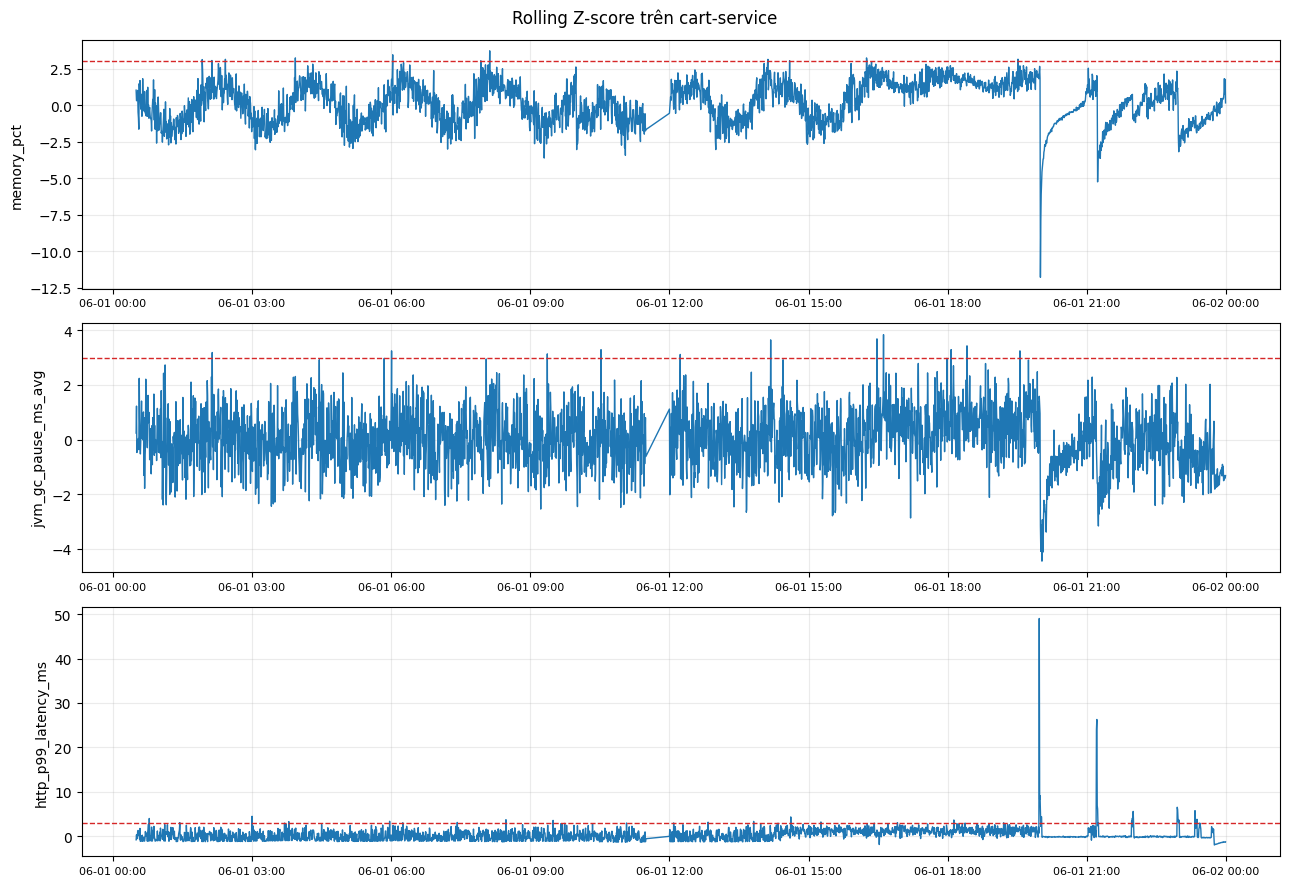

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, metric in zip(axes, ["memory_pct", "jvm_gc_pause_ms_avg", "http_p99_latency_ms"]):
    z = rolling_z(cart[metric].astype(float))
    ax.plot(cart["timestamp"], z, linewidth=1)
    ax.axhline(3, color="#d62728", linestyle="--", linewidth=1)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    format_time_axis(ax)
fig.suptitle("Rolling Z-score trên cart-service")
fig.tight_layout()
fig.savefig(PLOTS / "02_metric_rolling_z_cart.png", dpi=160)
plt.show()

**Rolling Z-score trên cart-service**

![Rolling Z-score trên cart-service](../plots/02_metric_rolling_z_cart.png)

## 2.4 Sustained threshold chỉ dùng để xác nhận vận hành

In [6]:
def first_sustained(df, series, threshold, points=5):
    mask = series >= threshold
    sustained = mask.rolling(points).sum() >= points
    if not sustained.any():
        return None
    idx = np.where(sustained)[0][0] - points + 1
    return df.loc[idx, "timestamp"], series.iloc[idx]

checks = [
    ("cart-service", "jvm_gc_pause_ms_avg", cart["jvm_gc_pause_ms_avg"], 100),
    ("cart-service", "memory_pct", cart["memory_pct"], 70),
    ("cart-service", "http_5xx_rate", cart["http_5xx_rate"], 5),
]
rows = []
for service, metric, series, threshold in checks:
    result = first_sustained(cart, series, threshold)
    if result:
        ts, value = result
        rows.append({"service": service, "metric": metric, "first_sustained": ts, "threshold": threshold, "value": value})
pd.DataFrame(rows)

,service,metric,first_sustained,threshold,value
0,cart-service,jvm_gc_pause_ms_avg,2026-06-01 18:06:00+00:00,100,107.300000
1,cart-service,memory_pct,2026-06-01 19:37:00+00:00,70,70.157821
2,cart-service,http_5xx_rate,2026-06-01 21:26:30+00:00,5,6.820000


## 2.5 Isolation Forest trên cart-service

In [7]:
feature_cols = ["memory_pct", "jvm_gc_pause_ms_avg", "http_p99_latency_ms", "http_5xx_rate", "restart_delta"]
features = cart[feature_cols].astype(float).ffill().bfill()
scaled = StandardScaler().fit_transform(features)

model = IsolationForest(n_estimators=300, contamination=0.04, random_state=42)
pred = model.fit_predict(scaled)
score = -model.decision_function(scaled)
cart["if_anomaly"] = pred == -1
cart["if_score"] = score

first_idx = cart.index[cart["if_anomaly"]][0]
cart.loc[first_idx, ["timestamp"] + feature_cols + ["if_score"]]

timestamp              2026-06-01 18:04:30+00:00
memory_pct                             49.170609
jvm_gc_pause_ms_avg                        161.1
http_p99_latency_ms                        361.1
http_5xx_rate                                2.0
restart_delta                                0.0
if_score                                 0.01746
Name: 2109, dtype: object

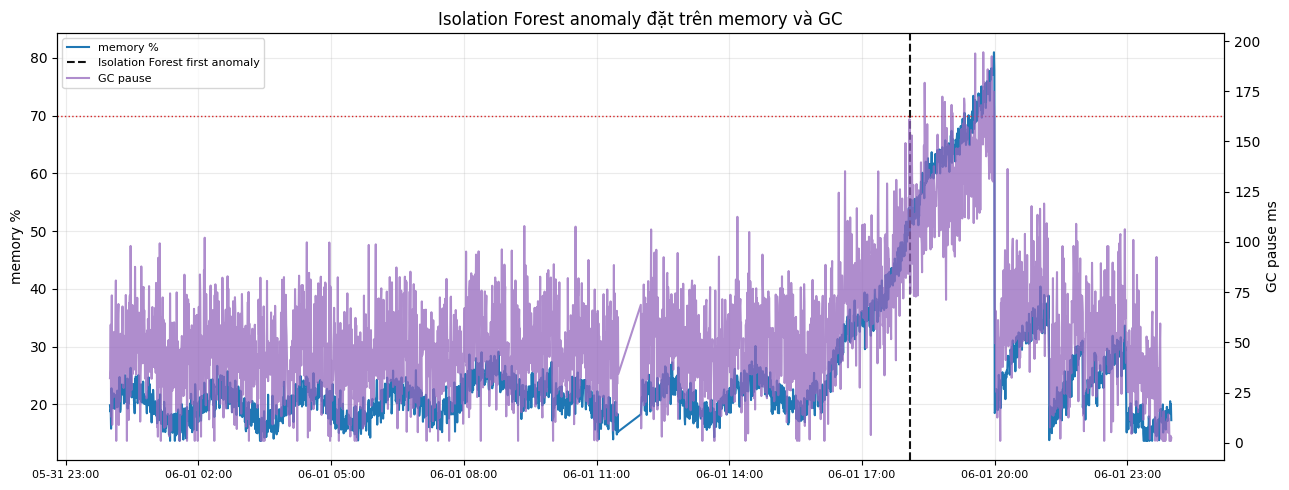

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cart["timestamp"], cart["memory_pct"], label="memory %", color="#1f77b4")
ax2 = ax.twinx()
ax2.plot(cart["timestamp"], cart["jvm_gc_pause_ms_avg"], label="GC pause", color="#9467bd", alpha=0.75)
ax.axvline(cart.loc[first_idx, "timestamp"], color="#111111", linestyle="--", label="Isolation Forest first anomaly")
ax.axhline(70, color="#d62728", linestyle=":", linewidth=1)
ax.set_title("Isolation Forest anomaly đặt trên memory và GC")
ax.set_ylabel("memory %")
ax2.set_ylabel("GC pause ms")
ax.grid(True, alpha=0.25)
format_time_axis(ax)
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(PLOTS / "02_metric_isolation_forest_cart.png", dpi=160)
plt.show()

**Isolation Forest trên cart-service**

![Isolation Forest trên cart-service](../plots/02_metric_isolation_forest_cart.png)

Isolation Forest bắt anomaly đầu tiên ở khoảng `18:04:30Z`, rất gần với mốc GC sustained anomaly `18:06Z`. Đây là evidence mạnh rằng `cart-service` đã bước vào trạng thái bất thường trước khi OOM và restart xảy ra.